device: cpu
Per-sample MSE: [7.0340542e-07 8.0760753e-07 1.4083893e-06 1.0223813e-06 5.6143122e-06
 1.2287329e-05]
Per-sample L2 : [0.02683816 0.02875744 0.03797618 0.03235612 0.07582252 0.11217051]
Mean MSE: 3.6405706396180904e-06  | Mean L2: 0.05232015624642372


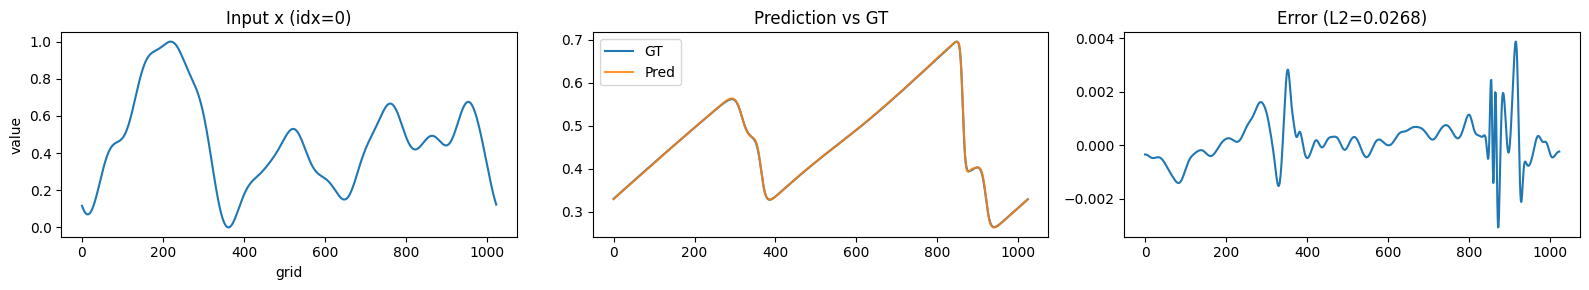

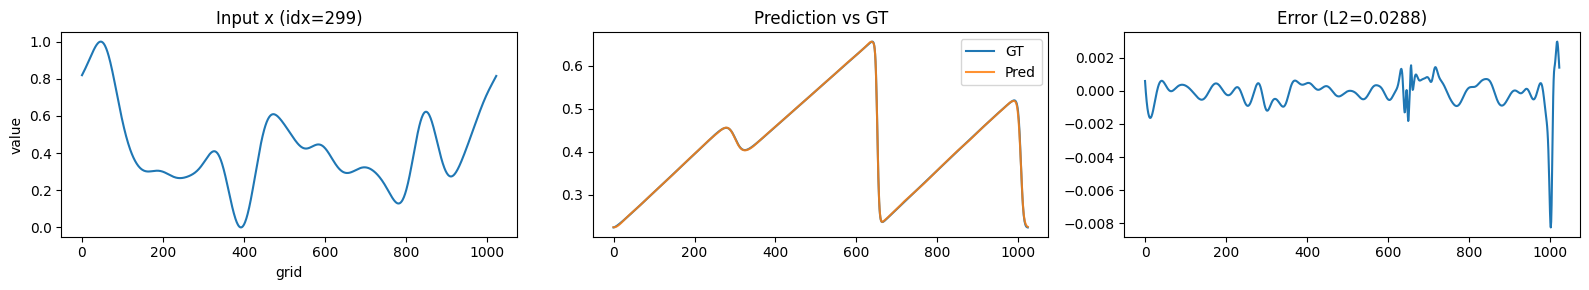

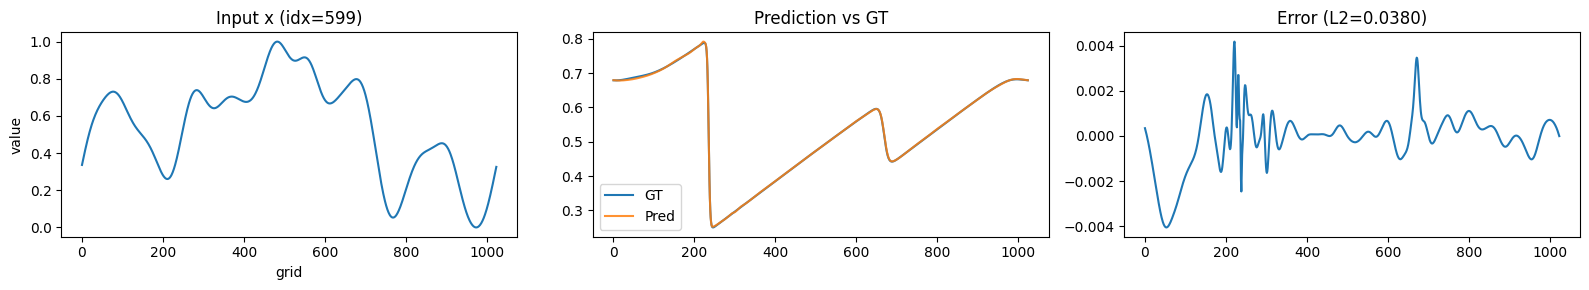

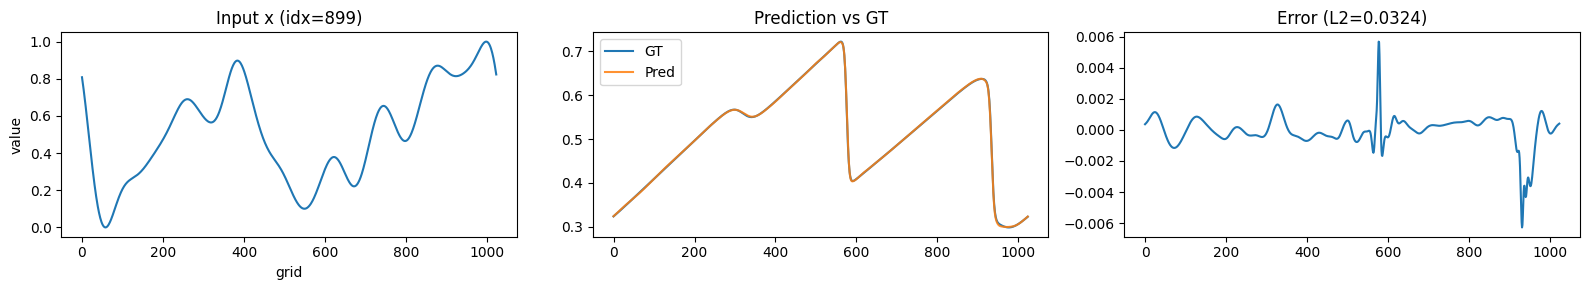

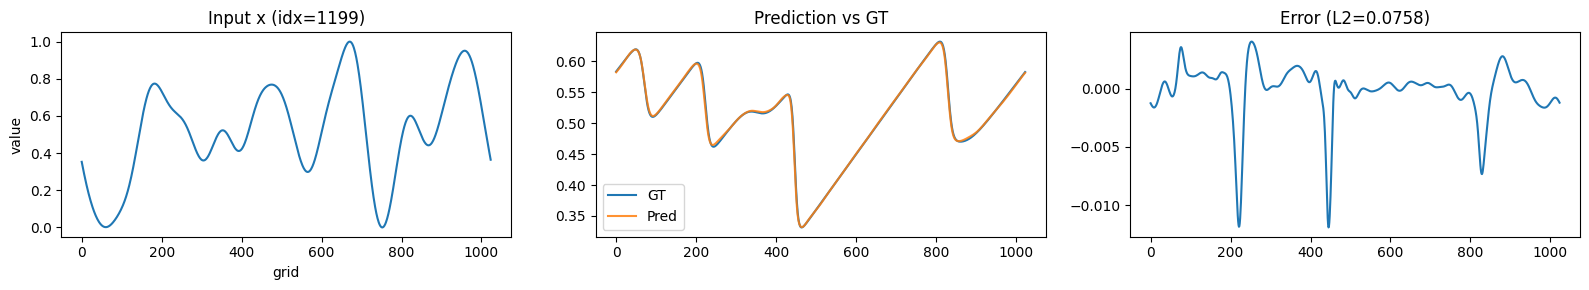

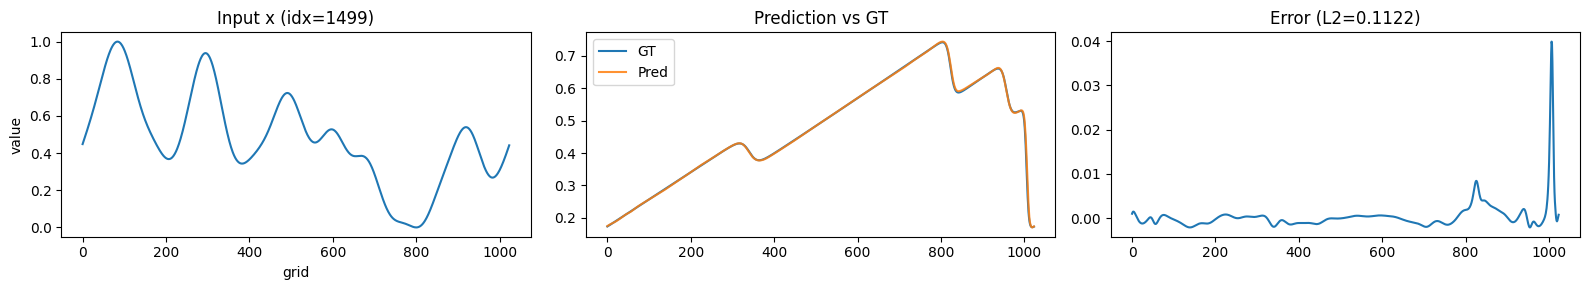

In [7]:
import torch, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 选择设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# ==== 路径（请按你的项目结构修改）====
nu_val = 0.0005
base_path = "/blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/1D_Burgers"
model_path = Path(f"{base_path}/saved_models/1D/modes16_width64_epochs500/pos/unnormalized/"
                  f"burgers_1d_FNO_model_trainedby_dim1d_nx1024_N1500_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu_val}_t1.0_seed45.pth")

data_path  = Path(f"{base_path}/datasets/1D/Burgers/pos/"
                  f"dim1d_nx1024_N1500_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu_val}_t1.0_seed45.pt")

assert model_path.exists(), f"模型文件不存在: {model_path}"
assert data_path.exists(),  f"数据文件不存在: {data_path}"

# ==== 导入你的 FNO1d 实现 ====
# 把这行改成你项目里 FNO1d 的实际导入方式
import sys
sys.path.append(base_path)
from models.FNO1d import FNO1d

modes, width = 16, 64

# ==== 读数据 ====
data = torch.load(data_path, map_location='cpu', weights_only=False)
if isinstance(data, dict) and 'x' in data and 'y' in data:
    x_all, y_all = data['x'].float(), data['y'].float()
else:
    raise ValueError("期望的数据文件是一个包含 'x' 和 'y' 的 dict(.pt)。")

# 统一形状到 (N, S); 如是 (N,S,1) 则 squeeze
if x_all.ndim == 3 and x_all.shape[-1] == 1:
    x_all = x_all.squeeze(-1)
if y_all.ndim == 3 and y_all.shape[-1] == 1:
    y_all = y_all.squeeze(-1)

# 下采样到训练分辨率 S=1024（与训练保持一致）
S_target = 1024
sub = x_all.shape[1] // S_target
if sub < 1:
    raise ValueError(f"当前数据分辨率 {x_all.shape[1]} 小于目标 {S_target}")
x_all = x_all[:, ::sub].contiguous()
y_all = y_all[:, ::sub].contiguous()

# ==== 构建并加载模型 ====
model = FNO1d(modes, width).to(device)
state = torch.load(model_path, map_location=device, weights_only=False)

# 兼容 DataParallel 的 'module.' 前缀
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', '', 1): v for k, v in state.items()}

missing, unexpected = model.load_state_dict(state, strict=False)
if missing:   print("[load] Missing keys:", missing)
if unexpected:print("[load] Unexpected keys:", unexpected)
model.eval();

# ==== 选样本做预测 ====
# 你可以手动指定，比如 idxs = [0, 1, 2, 3, 4, 5]
n_show = 6
idxs = np.linspace(0, len(x_all)-1, n_show, dtype=int)

with torch.no_grad():
    x_sel  = x_all[idxs]                      # (n_show, S)
    y_true = y_all[idxs]                      # (n_show, S)
    x_in   = x_sel.unsqueeze(-1).to(device)   # (n_show, S, 1)
    y_pred = model(x_in).squeeze(-1).cpu()    # (n_show, S)

# ==== 评估（简单 MSE/L2） ====
mse = torch.mean((y_pred - y_true)**2, dim=1)
l2  = torch.linalg.vector_norm((y_pred - y_true), ord=2, dim=1)
print("Per-sample MSE:", mse.numpy())
print("Per-sample L2 :", l2.numpy())
print("Mean MSE:", float(mse.mean()), " | Mean L2:", float(l2.mean()))

# ==== 画图（Input / Pred vs GT / Error）====
figs_dir = Path("figs"); figs_dir.mkdir(exist_ok=True, parents=True)

for i, idx in enumerate(idxs):
    fig, axes = plt.subplots(1, 3, figsize=(16, 3))

    # 1) 输入
    axes[0].plot(x_sel[i].numpy())
    axes[0].set_title(f"Input x (idx={idx})")
    axes[0].set_xlabel("grid"); axes[0].set_ylabel("value")

    # 2) 预测 vs 真值
    axes[1].plot(y_true[i].numpy(), label="GT", linewidth=1.5)
    axes[1].plot(y_pred[i].numpy(), label="Pred", linewidth=1.5, alpha=0.85)
    axes[1].set_title("Prediction vs GT"); axes[1].legend()

    # 3) 误差曲线
    err = (y_pred[i] - y_true[i]).numpy()
    axes[2].plot(err)
    axes[2].set_title(f"Error (L2={np.linalg.norm(err):.4f})")

    plt.tight_layout()
    fig.savefig(figs_dir / f"burgers_pred_idx{idx}.png", dpi=150)
    plt.show()
    plt.close(fig)

In [4]:
sys.path

['/blue/shiboli.fsu/yifeisun.umich/.conda/envs/adv_robust/lib/python310.zip',
 '/blue/shiboli.fsu/yifeisun.umich/.conda/envs/adv_robust/lib/python3.10',
 '/blue/shiboli.fsu/yifeisun.umich/.conda/envs/adv_robust/lib/python3.10/lib-dynload',
 '',
 '/blue/shiboli.fsu/yifeisun.umich/.conda/envs/adv_robust/lib/python3.10/site-packages',
 '/blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/1D_Burgers']

device: cpu
Per-sample MSE: [1.1802655e-08 3.2991895e-08 5.6492059e-08 1.4745908e-08 1.3039877e-08
 3.5631942e-08]
Per-sample L2 : [0.00347648 0.00581238 0.00760578 0.00388585 0.00365415 0.00604046]
Mean MSE: 2.745072258392156e-08  | Mean L2: 0.005079182330518961


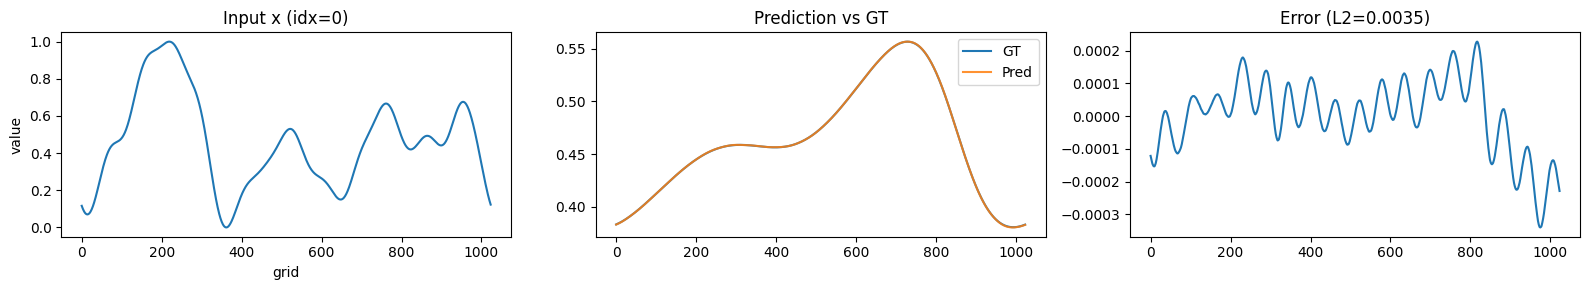

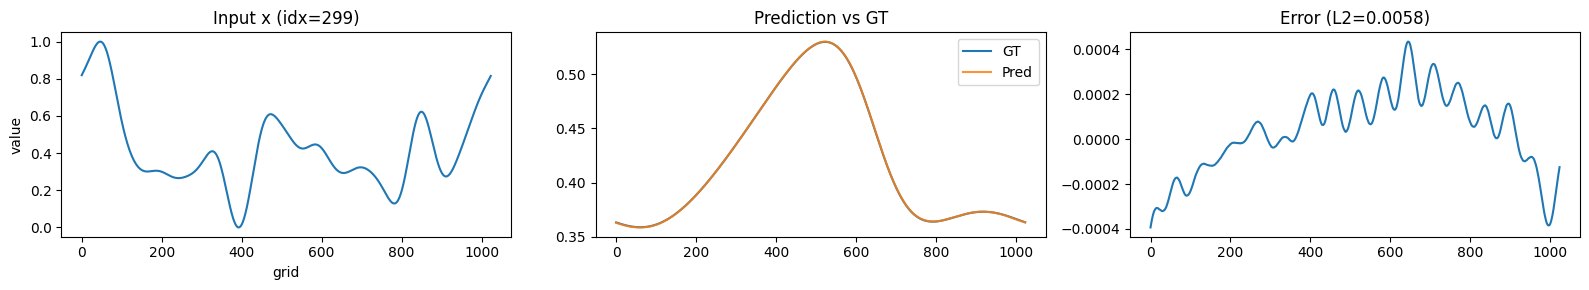

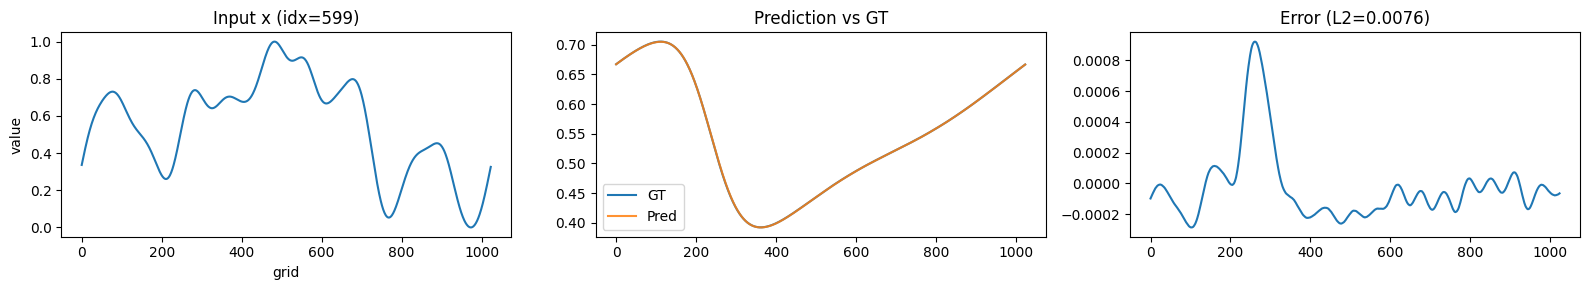

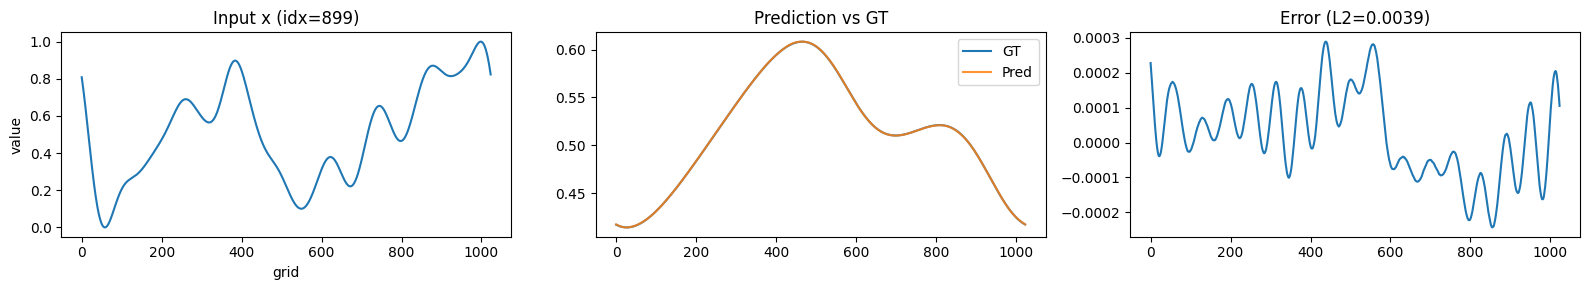

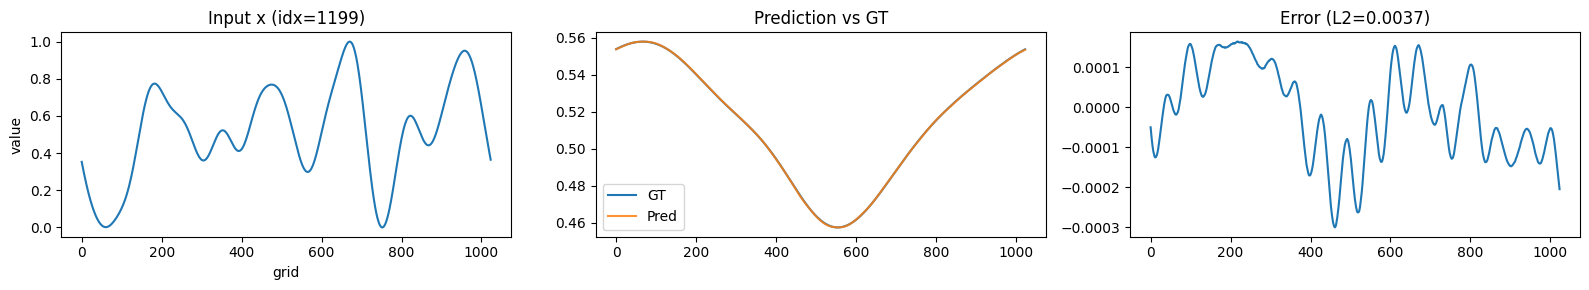

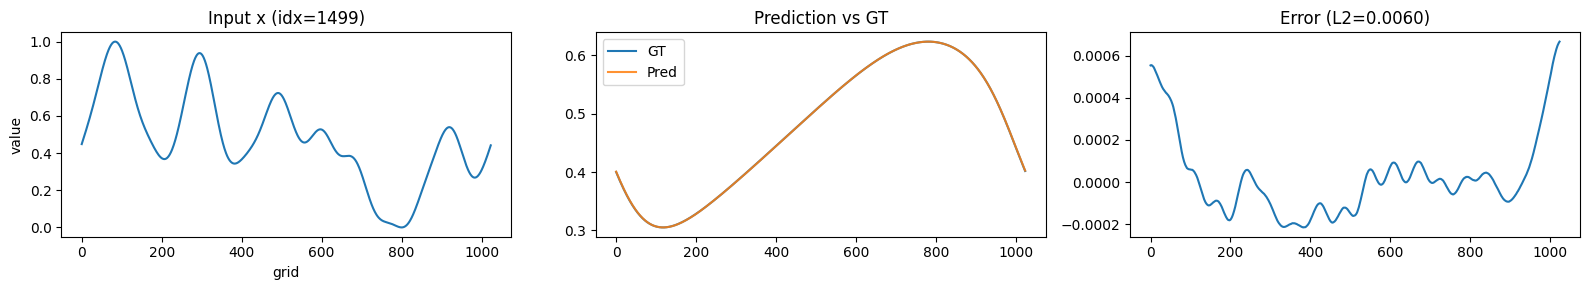

In [8]:
import torch, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 选择设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# ==== 路径（请按你的项目结构修改）====
nu_val = 0.01
base_path = "/blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/1D_Burgers"
model_path = Path(f"{base_path}/saved_models/1D/modes16_width64_epochs500/pos/unnormalized/"
                  f"burgers_1d_FNO_model_trainedby_dim1d_nx1024_N1500_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu_val}_t1.0_seed45.pth")

data_path  = Path(f"{base_path}/datasets/1D/Burgers/pos/"
                  f"dim1d_nx1024_N1500_solver=exponax_kernel=gaussian_correlation_length0.03_bcperiodic_nu{nu_val}_t1.0_seed45.pt")

assert model_path.exists(), f"模型文件不存在: {model_path}"
assert data_path.exists(),  f"数据文件不存在: {data_path}"

# ==== 导入你的 FNO1d 实现 ====
# 把这行改成你项目里 FNO1d 的实际导入方式
import sys
sys.path.append(base_path)
from models.FNO1d import FNO1d

modes, width = 16, 64

# ==== 读数据 ====
data = torch.load(data_path, map_location='cpu', weights_only=False)
if isinstance(data, dict) and 'x' in data and 'y' in data:
    x_all, y_all = data['x'].float(), data['y'].float()
else:
    raise ValueError("期望的数据文件是一个包含 'x' 和 'y' 的 dict(.pt)。")

# 统一形状到 (N, S); 如是 (N,S,1) 则 squeeze
if x_all.ndim == 3 and x_all.shape[-1] == 1:
    x_all = x_all.squeeze(-1)
if y_all.ndim == 3 and y_all.shape[-1] == 1:
    y_all = y_all.squeeze(-1)

# 下采样到训练分辨率 S=1024（与训练保持一致）
S_target = 1024
sub = x_all.shape[1] // S_target
if sub < 1:
    raise ValueError(f"当前数据分辨率 {x_all.shape[1]} 小于目标 {S_target}")
x_all = x_all[:, ::sub].contiguous()
y_all = y_all[:, ::sub].contiguous()

# ==== 构建并加载模型 ====
model = FNO1d(modes, width).to(device)
state = torch.load(model_path, map_location=device, weights_only=False)

# 兼容 DataParallel 的 'module.' 前缀
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', '', 1): v for k, v in state.items()}

missing, unexpected = model.load_state_dict(state, strict=False)
if missing:   print("[load] Missing keys:", missing)
if unexpected:print("[load] Unexpected keys:", unexpected)
model.eval();

# ==== 选样本做预测 ====
# 你可以手动指定，比如 idxs = [0, 1, 2, 3, 4, 5]
n_show = 6
idxs = np.linspace(0, len(x_all)-1, n_show, dtype=int)

with torch.no_grad():
    x_sel  = x_all[idxs]                      # (n_show, S)
    y_true = y_all[idxs]                      # (n_show, S)
    x_in   = x_sel.unsqueeze(-1).to(device)   # (n_show, S, 1)
    y_pred = model(x_in).squeeze(-1).cpu()    # (n_show, S)

# ==== 评估（简单 MSE/L2） ====
mse = torch.mean((y_pred - y_true)**2, dim=1)
l2  = torch.linalg.vector_norm((y_pred - y_true), ord=2, dim=1)
print("Per-sample MSE:", mse.numpy())
print("Per-sample L2 :", l2.numpy())
print("Mean MSE:", float(mse.mean()), " | Mean L2:", float(l2.mean()))

# ==== 画图（Input / Pred vs GT / Error）====
figs_dir = Path("figs"); figs_dir.mkdir(exist_ok=True, parents=True)

for i, idx in enumerate(idxs):
    fig, axes = plt.subplots(1, 3, figsize=(16, 3))

    # 1) 输入
    axes[0].plot(x_sel[i].numpy())
    axes[0].set_title(f"Input x (idx={idx})")
    axes[0].set_xlabel("grid"); axes[0].set_ylabel("value")

    # 2) 预测 vs 真值
    axes[1].plot(y_true[i].numpy(), label="GT", linewidth=1.5)
    axes[1].plot(y_pred[i].numpy(), label="Pred", linewidth=1.5, alpha=0.85)
    axes[1].set_title("Prediction vs GT"); axes[1].legend()

    # 3) 误差曲线
    err = (y_pred[i] - y_true[i]).numpy()
    axes[2].plot(err)
    axes[2].set_title(f"Error (L2={np.linalg.norm(err):.4f})")

    plt.tight_layout()
    fig.savefig(figs_dir / f"burgers_pred_idx{idx}.png", dpi=150)
    plt.show()
    plt.close(fig)